# 🎬 Notebook 1 — FAISS with Movie Plots

> **Goal:** learn the foundational vector search library every other tool is benchmarked against.

## 🎯 Learning Goals
- Encode text into vectors with a sentence transformer
- Build a **FlatL2** (exact) and an **HNSW** (approximate) index
- Compare exact vs approximate search
- Visualize embeddings in 2D

## 🍱 Analogy
**FAISS = a librarian's card catalog.**
- The **books** are your vectors.
- A **Flat** index reads every card. Slow but perfect.
- An **HNSW** index follows cross-references. Fast and almost-perfect.

FAISS stores **only vectors + IDs**. Metadata (title, year…) lives in your own Python dict.

In [1]:
# 📦 First run only — uncomment to install
%pip install -q faiss-cpu sentence-transformers numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


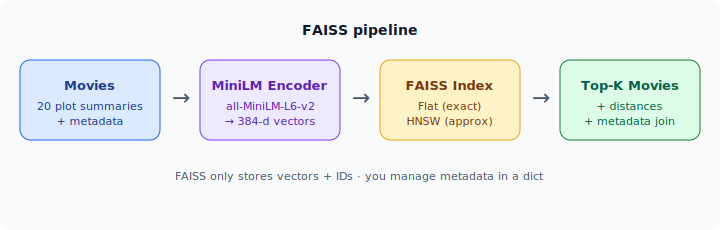

In [1]:
# 🖼️ What we're building
from IPython.display import SVG
SVG("""<svg viewBox="0 0 720 230" xmlns="http://www.w3.org/2000/svg" width="720"><style>text{font-family:Inter,system-ui,sans-serif}</style><rect width="720" height="230" fill="#f8fafc" rx="12"/><rect x="20" y="60" width="140" height="80" rx="10" fill="#dbeafe" stroke="#2563eb"/><text x="90" y="90" text-anchor="middle" font-size="13" font-weight="700" fill="#1e3a8a">Movies</text><text x="90" y="110" text-anchor="middle" font-size="11" fill="#1e3a8a">20 plot summaries</text><text x="90" y="125" text-anchor="middle" font-size="11" fill="#1e3a8a">+ metadata</text><rect x="200" y="60" width="140" height="80" rx="10" fill="#ede9fe" stroke="#7c3aed"/><text x="270" y="90" text-anchor="middle" font-size="13" font-weight="700" fill="#5b21b6">MiniLM Encoder</text><text x="270" y="110" text-anchor="middle" font-size="11" fill="#5b21b6">all-MiniLM-L6-v2</text><text x="270" y="125" text-anchor="middle" font-size="11" fill="#5b21b6">→ 384-d vectors</text><rect x="380" y="60" width="140" height="80" rx="10" fill="#fef3c7" stroke="#f59e0b"/><text x="450" y="90" text-anchor="middle" font-size="13" font-weight="700" fill="#78350f">FAISS Index</text><text x="450" y="110" text-anchor="middle" font-size="11" fill="#78350f">Flat (exact)</text><text x="450" y="125" text-anchor="middle" font-size="11" fill="#78350f">HNSW (approx)</text><rect x="560" y="60" width="140" height="80" rx="10" fill="#dcfce7" stroke="#15803d"/><text x="630" y="90" text-anchor="middle" font-size="13" font-weight="700" fill="#065f46">Top-K Movies</text><text x="630" y="110" text-anchor="middle" font-size="11" fill="#065f46">+ distances</text><text x="630" y="125" text-anchor="middle" font-size="11" fill="#065f46">+ metadata join</text><text x="172" y="105" font-size="22" fill="#475569">→</text><text x="352" y="105" font-size="22" fill="#475569">→</text><text x="532" y="105" font-size="22" fill="#475569">→</text><text x="360" y="35" text-anchor="middle" font-size="14" font-weight="700" fill="#0f172a">FAISS pipeline</text><text x="360" y="180" text-anchor="middle" font-size="11" fill="#475569">FAISS only stores vectors + IDs · you manage metadata in a dict</text></svg>""")

In [2]:
# 🎬 20 famous movies with plot + metadata
movies = [
    {"id": 0,  "title": "Inception",          "year": 2010, "genre": "Sci-Fi",    "rating": 8.8, "plot": "A thief steals corporate secrets through dream-sharing technology and is tasked with planting an idea into a CEO's mind."},
    {"id": 1,  "title": "The Matrix",         "year": 1999, "genre": "Sci-Fi",    "rating": 8.7, "plot": "A computer hacker learns about the true nature of reality and his role in the war against its controllers in a simulation."},
    {"id": 2,  "title": "Interstellar",       "year": 2014, "genre": "Sci-Fi",    "rating": 8.6, "plot": "A team of explorers travel through a wormhole in space to ensure humanity's survival as Earth dies."},
    {"id": 3,  "title": "Blade Runner 2049",  "year": 2017, "genre": "Sci-Fi",    "rating": 8.0, "plot": "A young blade runner discovers a buried secret leading him on a quest to find a former blade runner missing for thirty years."},
    {"id": 4,  "title": "Arrival",            "year": 2016, "genre": "Sci-Fi",    "rating": 7.9, "plot": "A linguist works with the military to communicate with alien lifeforms after twelve mysterious spacecraft appear around the world."},
    {"id": 5,  "title": "The Godfather",      "year": 1972, "genre": "Crime",     "rating": 9.2, "plot": "An organized crime dynasty's aging patriarch transfers control of his clandestine empire to his reluctant son."},
    {"id": 6,  "title": "Pulp Fiction",       "year": 1994, "genre": "Crime",     "rating": 8.9, "plot": "The lives of two mob hitmen, a boxer, and a gangster's wife intertwine in tales of violence and redemption."},
    {"id": 7,  "title": "Goodfellas",         "year": 1990, "genre": "Crime",     "rating": 8.7, "plot": "The story of Henry Hill and his life in the mob, his marriage, and his complicated mob partnerships."},
    {"id": 8,  "title": "The Dark Knight",    "year": 2008, "genre": "Action",    "rating": 9.0, "plot": "Batman raises the stakes in his war on crime when the Joker wreaks havoc on the people of Gotham."},
    {"id": 9,  "title": "Mad Max: Fury Road", "year": 2015, "genre": "Action",    "rating": 8.1, "plot": "In a post-apocalyptic wasteland a woman rebels against a tyrannical ruler in search of her homeland with the aid of a survivor."},
    {"id": 10, "title": "Gladiator",          "year": 2000, "genre": "Action",    "rating": 8.5, "plot": "A former Roman general sets out to exact vengeance against the corrupt emperor who murdered his family and sent him into slavery."},
    {"id": 11, "title": "The Notebook",       "year": 2004, "genre": "Romance",   "rating": 7.8, "plot": "A poor passionate young man falls in love with a rich young woman, giving her freedom, but they are soon separated."},
    {"id": 12, "title": "La La Land",         "year": 2016, "genre": "Romance",   "rating": 8.0, "plot": "A jazz pianist falls for an aspiring actress in Los Angeles while pursuing dreams in a city that crushes hopes."},
    {"id": 13, "title": "Titanic",            "year": 1997, "genre": "Romance",   "rating": 7.9, "plot": "A seventeen-year-old aristocrat falls in love with a kind but poor artist aboard the luxurious, ill-fated R.M.S. Titanic."},
    {"id": 14, "title": "Toy Story",          "year": 1995, "genre": "Animation", "rating": 8.3, "plot": "A cowboy doll is profoundly threatened and jealous when a new spaceman action figure becomes a boy's favorite toy."},
    {"id": 15, "title": "Spirited Away",      "year": 2001, "genre": "Animation", "rating": 8.6, "plot": "During her family's move, a girl wanders into a world ruled by gods and witches where humans are turned into beasts."},
    {"id": 16, "title": "Finding Nemo",       "year": 2003, "genre": "Animation", "rating": 8.2, "plot": "After his son is captured at the Great Barrier Reef, a timid clownfish sets out on a journey to bring him home from Sydney."},
    {"id": 17, "title": "The Shining",        "year": 1980, "genre": "Horror",    "rating": 8.4, "plot": "A family heads to an isolated hotel for the winter where a sinister presence influences the father into violence."},
    {"id": 18, "title": "Get Out",            "year": 2017, "genre": "Horror",    "rating": 7.7, "plot": "A young Black man visits his white girlfriend's parents for the weekend, where his uneasiness about their reception reaches a boiling point."},
    {"id": 19, "title": "Hereditary",         "year": 2018, "genre": "Horror",    "rating": 7.3, "plot": "A grieving family is haunted by tragic and disturbing occurrences after the death of their secretive grandmother."},
]
import pandas as pd
df = pd.DataFrame(movies)
df.head()

,id,title,year,genre,rating,plot
0,0,Inception,2010,Sci-Fi,8.8,A thief steals corporate secrets through dream...
1,1,The Matrix,1999,Sci-Fi,8.7,A computer hacker learns about the true nature...
2,2,Interstellar,2014,Sci-Fi,8.6,A team of explorers travel through a wormhole ...
3,3,Blade Runner 2049,2017,Sci-Fi,8.0,A young blade runner discovers a buried secret...
4,4,Arrival,2016,Sci-Fi,7.9,A linguist works with the military to communic...


In [3]:
# 🧠 Encode plots with a small sentence transformer (~80MB, CPU-friendly)
from sentence_transformers import SentenceTransformer
import numpy as np

encoder = SentenceTransformer("all-MiniLM-L6-v2")
plots = [m["plot"] for m in movies]
vectors = encoder.encode(plots, normalize_embeddings=False).astype("float32")
print("Vectors shape:", vectors.shape)   # (20, 384)
print("First 8 dims of vector[0]:", vectors[0][:8])

c:\Users\81191673\OneDrive - Pepsico\Desktop\docs\vector-db-notebooks\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\81191673\OneDrive - Pepsico\Desktop\docs\vector-db-notebooks\.venv\lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\81191673\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you ei

Vectors shape: (20, 384)
First 8 dims of vector[0]: [-0.0717986   0.03907971  0.03352024 -0.04037247  0.01391939  0.05454958
  0.09850423 -0.01127885]


## 🗂️ Build two FAISS indexes
- **IndexFlatL2** — brute force; 100% recall.
- **IndexHNSWFlat** — graph-based; ~95–99% recall, sub-linear search.

Same code scales from 20 to 100M vectors.

In [4]:
import faiss
dim = vectors.shape[1]   # 384

# Exact index
index_flat = faiss.IndexFlatL2(dim)
index_flat.add(vectors)

# Approximate HNSW index — M = neighbors-per-node in the graph
index_hnsw = faiss.IndexHNSWFlat(dim, 16)
index_hnsw.hnsw.efConstruction = 64   # build quality
index_hnsw.hnsw.efSearch = 32         # query recall vs latency
index_hnsw.add(vectors)

print(f"Flat: {index_flat.ntotal} vectors | HNSW: {index_hnsw.ntotal} vectors")

Flat: 20 vectors | HNSW: 20 vectors


In [5]:
# 🔍 Helper — pretty-print top-K results joined with metadata
def search(index, query, k=5, label=""):
    qv = encoder.encode([query]).astype("float32")
    D, I = index.search(qv, k)
    print(f"\n🔎 {label} | \"{query}\"")
    rows = [{"rank": r+1, "title": movies[i]["title"], "genre": movies[i]["genre"],
             "year": movies[i]["year"], "distance": round(float(d), 3)}
            for r, (i, d) in enumerate(zip(I[0], D[0]))]
    return pd.DataFrame(rows)

search(index_flat, "a man trapped inside dreams and illusions", label="FLAT (exact)")


🔎 FLAT (exact) | "a man trapped inside dreams and illusions"


,rank,title,genre,year,distance
0,1,Inception,Sci-Fi,2010,1.187
1,2,The Matrix,Sci-Fi,1999,1.338
2,3,La La Land,Romance,2016,1.579
3,4,Hereditary,Horror,2018,1.580
4,5,Titanic,Romance,1997,1.624


In [6]:
search(index_hnsw, "a man trapped inside dreams and illusions", label="HNSW (approx)")


🔎 HNSW (approx) | "a man trapped inside dreams and illusions"


,rank,title,genre,year,distance
0,1,Inception,Sci-Fi,2010,1.187
1,2,The Matrix,Sci-Fi,1999,1.338
2,3,La La Land,Romance,2016,1.579
3,4,Hereditary,Horror,2018,1.580
4,5,Titanic,Romance,1997,1.624


In [7]:
search(index_flat, "love story across social classes that ends in tragedy", label="FLAT")


🔎 FLAT | "love story across social classes that ends in tragedy"


,rank,title,genre,year,distance
0,1,Pulp Fiction,Crime,1994,1.166
1,2,Goodfellas,Crime,1990,1.175
2,3,The Notebook,Romance,2004,1.201
3,4,Hereditary,Horror,2018,1.290
4,5,The Shining,Horror,1980,1.373


In [8]:
# 🧪 Filtering — FAISS can't filter natively. Pattern: over-fetch, then filter.
def search_with_filter(query, genre, k=10):
    qv = encoder.encode([query]).astype("float32")
    D, I = index_flat.search(qv, k)
    rows = [{"title": movies[i]["title"], "year": movies[i]["year"],
             "rating": movies[i]["rating"], "distance": round(float(d), 3)}
            for i, d in zip(I[0], D[0]) if movies[i]["genre"] == genre]
    return pd.DataFrame(rows)

search_with_filter("a thief invades dreams to plant ideas", genre="Sci-Fi")

,title,year,rating,distance
0,Inception,2010,8.8,0.653
1,The Matrix,1999,8.7,1.550
2,Blade Runner 2049,2017,8.0,1.635


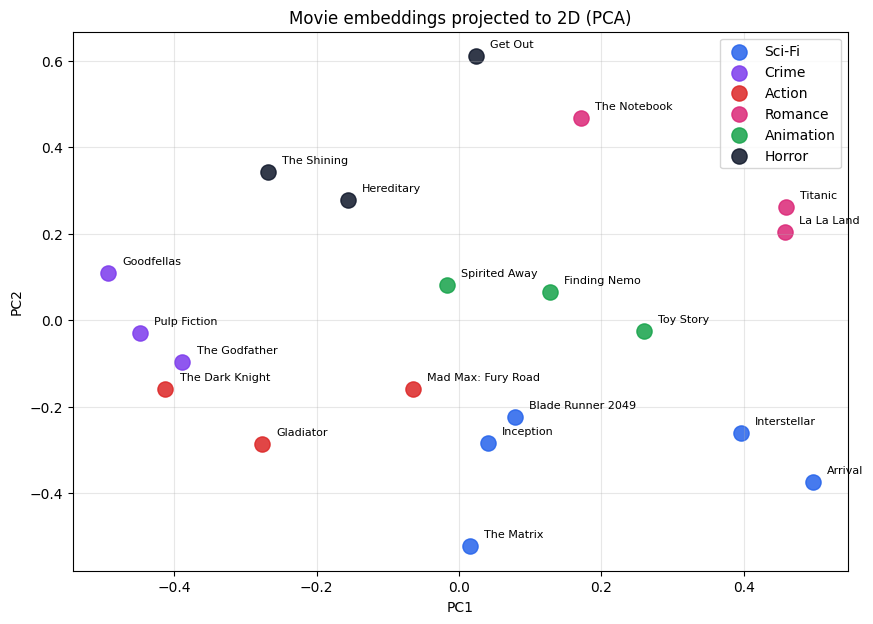

In [9]:
# 🎨 Visualize embeddings in 2D — same-genre movies should cluster
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

coords = PCA(n_components=2).fit_transform(vectors)
colors = {"Sci-Fi":"#2563eb","Crime":"#7c3aed","Action":"#dc2626",
          "Romance":"#db2777","Animation":"#16a34a","Horror":"#0f172a"}

plt.figure(figsize=(10, 7))
for g in df["genre"].unique():
    m = df["genre"] == g
    plt.scatter(coords[m, 0], coords[m, 1], c=colors[g], s=120, label=g, alpha=0.85)
for i, mv in enumerate(movies):
    plt.annotate(mv["title"], (coords[i,0]+0.02, coords[i,1]+0.02), fontsize=8)
plt.title("Movie embeddings projected to 2D (PCA)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 🏋️ Exercises
1. **Add 5 movies** of any genre and re-run. Do they cluster correctly in 2D?
2. **Tune `efSearch`** on HNSW (4, 16, 64, 200). Describe what would change at 10M vectors.
3. **Cosine search** — `faiss.normalize_L2(vectors)` then use `IndexFlatIP`. Compare results.

## 🎓 Recap — When to use FAISS
✅ Embedded inside your app (max speed, GPU support)
✅ Research / benchmarking index types
❌ Need REST API, replication, managed service → use Qdrant / Weaviate / Pinecone